# Portfolio 1 — Bayesian Analysis: Vitamin A & Vaccine Response
## Notebook 01: Data Simulation

**Goal:** Reconstruct patient-level data from published trial summary statistics (NCT02649192)
and verify the simulation matches the reported seroconversion rates.

**Trial:** Vitamin A+D supplementation vs placebo — H1N1 seroconversion in children (n=66, two seasons)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

## Step 1: Define trial parameters from published summary statistics

In [2]:
# Season 2 (2016-2017)
s2_ad_n = 21
s2_ad_seroconverted = 15
s2_placebo_n = 20
s2_placebo_seroconverted = 19

# Season 3 (2017-2018)
s3_ad_n = 11
s3_ad_seroconverted = 8
s3_placebo_n = 14
s3_placebo_seroconverted = 12

print("Season 2 - A&D group: {}/{} = {:.1%}".format(s2_ad_seroconverted, s2_ad_n, s2_ad_seroconverted/s2_ad_n))
print("Season 2 - Placebo: {}/{} = {:.1%}".format(s2_placebo_seroconverted, s2_placebo_n, s2_placebo_seroconverted/s2_placebo_n))
print("\nSeason 3 - A&D group: {}/{} = {:.1%}".format(s3_ad_seroconverted, s3_ad_n, s3_ad_seroconverted/s3_ad_n))
print("Season 3 - Placebo: {}/{} = {:.1%}".format(s3_placebo_seroconverted, s3_placebo_n, s3_placebo_seroconverted/s3_placebo_n))

Season 2 - A&D group: 15/21 = 71.4%
Season 2 - Placebo: 19/20 = 95.0%

Season 3 - A&D group: 8/11 = 72.7%
Season 3 - Placebo: 12/14 = 85.7%


## Step 2: Simulate patient-level data

In [3]:
def simulate_group(season, treatment, n_total, n_seroconverted):
    outcomes = np.array([1] * n_seroconverted + [0] * (n_total - n_seroconverted))
    np.random.shuffle(outcomes)
    df = pd.DataFrame({
        'participant_id': range(1, n_total + 1),
        'season': season,
        'treatment': treatment,
        'seroconverted': outcomes
    })
    return df

s2_ad      = simulate_group('S2', 'A&D',     s2_ad_n,      s2_ad_seroconverted)
s2_placebo = simulate_group('S2', 'Placebo', s2_placebo_n, s2_placebo_seroconverted)
s3_ad      = simulate_group('S3', 'A&D',     s3_ad_n,      s3_ad_seroconverted)
s3_placebo = simulate_group('S3', 'Placebo', s3_placebo_n, s3_placebo_seroconverted)

df = pd.concat([s2_ad, s2_placebo, s3_ad, s3_placebo], ignore_index=True)
df['participant_id'] = range(1, len(df) + 1)

print(f"Total participants: {len(df)}")
df.head()

Total participants: 66


,participant_id,season,treatment,seroconverted
0,1,S2,A&D,1
1,2,S2,A&D,0
2,3,S2,A&D,0
3,4,S2,A&D,1
4,5,S2,A&D,1


## Step 3: Verify simulated data matches reported statistics

In [4]:
summary = df.groupby(['season', 'treatment']).agg({
    'seroconverted': ['count', 'sum', 'mean']
}).round(3)
summary.columns = ['n_total', 'n_seroconverted', 'rate']
summary['percentage'] = (summary['rate'] * 100).round(1).astype(str) + '%'

print("=== SIMULATED DATA SUMMARY ===")
print(summary)

print("\n=== COMPARISON TO REPORTED STATISTICS ===")
print(f"S2 A&D:      {summary.loc[('S2', 'A&D'), 'percentage']} vs 71.4% (reported)")
print(f"S2 Placebo:  {summary.loc[('S2', 'Placebo'), 'percentage']} vs 95.0% (reported)")
print(f"S3 A&D:      {summary.loc[('S3', 'A&D'), 'percentage']} vs 72.7% (reported)")
print(f"S3 Placebo:  {summary.loc[('S3', 'Placebo'), 'percentage']} vs 85.7% (reported)")

=== SIMULATED DATA SUMMARY ===
                  n_total  n_seroconverted   rate percentage
season treatment                                            
S2     A&D             21               15  0.714      71.4%
       Placebo         20               19  0.950      95.0%
S3     A&D             11                8  0.727      72.7%
       Placebo         14               12  0.857      85.7%

=== COMPARISON TO REPORTED STATISTICS ===
S2 A&D:      71.4% vs 71.4% (reported)
S2 Placebo:  95.0% vs 95.0% (reported)
S3 A&D:      72.7% vs 72.7% (reported)
S3 Placebo:  85.7% vs 85.7% (reported)


## Step 4: Visualise seroconversion rates by group

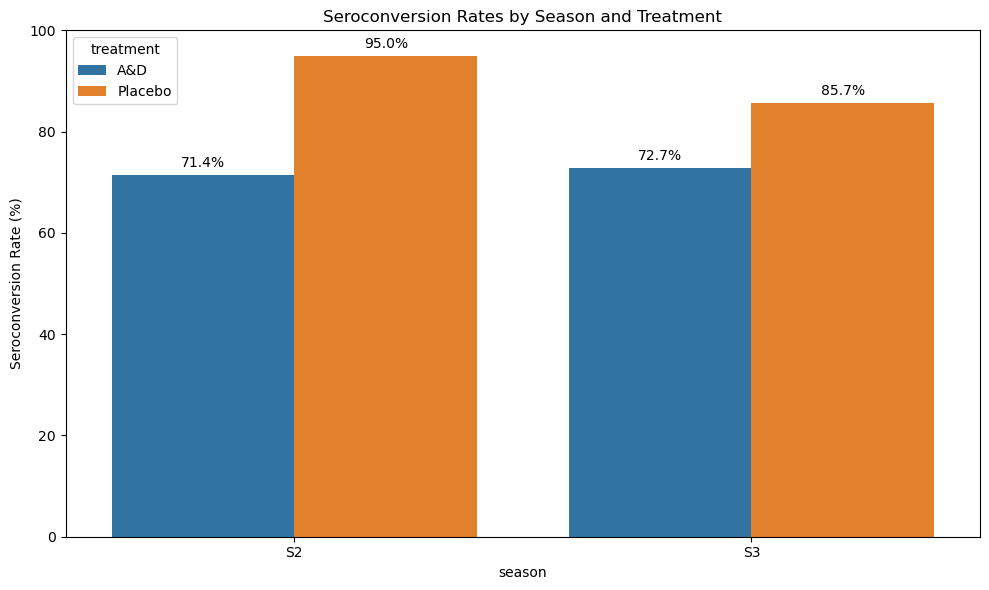

Saved: ../figures/seroconversion_by_group.png


In [5]:
plot_data = df.groupby(['season', 'treatment'], as_index=False).agg(rate=('seroconverted', 'mean'))
plot_data['rate_pct'] = plot_data['rate'] * 100

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=plot_data, x='season', y='rate_pct', hue='treatment', ax=ax)

for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 1,
            f'{p.get_height():.1f}%', ha='center', va='bottom')

plt.ylim(0, 100)
plt.ylabel('Seroconversion Rate (%)')
plt.title('Seroconversion Rates by Season and Treatment')
plt.tight_layout()
plt.savefig('../figures/seroconversion_by_group.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: ../figures/seroconversion_by_group.png")

## Step 5: Calculate observed Odds Ratios

OR < 1: A&D has *lower* odds of seroconversion than Placebo (unexpected direction)
OR = 1: No difference
OR > 1: A&D increases odds of seroconversion

In [6]:
def calculate_odds_ratio(treatment_successes, treatment_total, placebo_successes, placebo_total):
    treatment_failures = treatment_total - treatment_successes
    placebo_failures   = placebo_total   - placebo_successes
    treatment_odds = treatment_successes / treatment_failures if treatment_failures > 0 else float('inf')
    placebo_odds   = placebo_successes   / placebo_failures   if placebo_failures   > 0 else float('inf')
    return treatment_odds / placebo_odds, treatment_odds, placebo_odds

s2_or, s2_treat_odds, s2_plac_odds = calculate_odds_ratio(s2_ad_seroconverted, s2_ad_n, s2_placebo_seroconverted, s2_placebo_n)
s3_or, s3_treat_odds, s3_plac_odds = calculate_odds_ratio(s3_ad_seroconverted, s3_ad_n, s3_placebo_seroconverted, s3_placebo_n)

print("=== ODDS RATIOS (A&D vs Placebo) ===")
for season, OR, treat_odds, plac_odds in [('S2', s2_or, s2_treat_odds, s2_plac_odds),
                                           ('S3', s3_or, s3_treat_odds, s3_plac_odds)]:
    print(f"\n{season}:  A&D odds={treat_odds:.2f}  Placebo odds={plac_odds:.2f}  OR={OR:.2f}")
    print(f"  {'A&D REDUCES seroconversion (OR < 1) — unexpected!' if OR < 1 else 'A&D INCREASES seroconversion (OR > 1)'}")

print("\nNote: OR < 1.0 is opposite of the expected direction (vitamin A should improve immune response).")
print("This motivates the Bayesian analysis: quantifying effect size + uncertainty in small samples.")

=== ODDS RATIOS (A&D vs Placebo) ===

S2:  A&D odds=2.50  Placebo odds=19.00  OR=0.13
  A&D REDUCES seroconversion (OR < 1) — unexpected!

S3:  A&D odds=2.67  Placebo odds=6.00  OR=0.44
  A&D REDUCES seroconversion (OR < 1) — unexpected!

Note: OR < 1.0 is opposite of the expected direction (vitamin A should improve immune response).
This motivates the Bayesian analysis: quantifying effect size + uncertainty in small samples.


## Step 6: Save simulated data to CSV

In [7]:
df.to_csv('../data/simulated_patient_data.csv', index=False)
print(f"Saved: ../data/simulated_patient_data.csv  ({len(df)} rows)")
df.head(10)

Saved: ../data/simulated_patient_data.csv  (66 rows)


,participant_id,season,treatment,seroconverted
0,1,S2,A&D,1
1,2,S2,A&D,0
2,3,S2,A&D,0
3,4,S2,A&D,1
4,5,S2,A&D,1
5,6,S2,A&D,1
6,7,S2,A&D,1
7,8,S2,A&D,1
8,9,S2,A&D,0
9,10,S2,A&D,0
